In [1]:
import json
import numpy as np
from openai import OpenAI, AsyncOpenAI
import openai
from collections import defaultdict
import pytrec_eval
from string import Template
import random
print(openai.__version__)

from scipy.optimize import curve_fit
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import statistics

client = AsyncOpenAI(
    api_key=snowflake_key,
    base_url=snowflake_base_url
)

random.seed(0)

1.90.0


In [2]:
import sys
sys.path.append('./..')
from order_by.sorting import *
from order_by.utils import *
from prompts.all_prompts import *
from order_by.pointwise import *

In [3]:
from dataclasses import dataclass
from tqdm import tqdm

@dataclass
class SearchResult:
    docid: str
    score: float
    text: str

In [4]:
import pandas as pd

df = pd.read_csv('../data/rotten_tomatoes_movie_reviews.csv')
# Extract numerator and denominator
score_split = df["originalScore"].str.extract(r'(?P<num>[\d\.]+)/(?P<den>[\d\.]+)')

# Compute float value; if no denominator, just use numerator
df["originalScore_float"] = pd.to_numeric(score_split["num"], errors="coerce") / pd.to_numeric(score_split["den"], errors="coerce")

# Drop rows where conversion failed
df_clean = df.dropna(subset=["originalScore_float"]).copy()

# Filter for specific movie
sub = df_clean[df_clean["id"] == "ant_man_and_the_wasp_quantumania"]

# Sort descending
sub_sorted = sub.sort_values(by="originalScore_float", ascending=False).reset_index(drop=True)

print("Total rows:", len(sub_sorted))
print("Unique reviewIds:", sub_sorted["reviewId"].nunique())

qrels_by_qid = {
    "ant_man_and_the_wasp_quantumania":
    {str(row["reviewId"]): int(row["originalScore_float"]*10) for _, row in sub_sorted.iterrows()}
}
# print(qrels_by_qid)
print(len(qrels_by_qid['ant_man_and_the_wasp_quantumania']))

Total rows: 456
Unique reviewIds: 228
228


In [5]:
query_map = {}
for _, row in sub_sorted.iterrows():
    # Use reviewId as the key
    review_id = str(row["reviewId"])
    review_text = str(row["reviewText"])
    query_map[review_id] = review_text

print("Number of entries in query_map:", len(query_map))


Number of entries in query_map: 228


In [6]:
class SafeDict(dict):
    def __missing__(self, k):  # leave untouched
        return '{' + k + '}'
evaluator = pytrec_eval.RelevanceEvaluator(qrels_by_qid, {'ndcg_cut.10'})


In [7]:
def add_result(results, model, alg, acc, price, token, query_acc, query_alg=None):
    results[model]['alg'].append(alg)
    results[model]['acc'].append(acc)
    results[model]['price'].append(price)
    results[model]['token'].append(token)
    results[model]['query_acc'].append(query_acc)
    if query_alg:
        results[model]['query_alg'].append(query_alg)
        assert abs(acc - sum(query_acc)/len(query_acc)) < 0.1
results = {}
optimizer_results = {}

for modelname in ["llama3.1-70b", 'llama3.1-405b', 'mistral-7b']:
    results[modelname] = {'alg':[], 'price':[], 'token':[], 'acc':[], 'query_acc':[]}
    optimizer_results[modelname] = {'alg':[], 'price':[], 'token':[], 'acc':[], 'query_acc':[], 'query_alg':[]}

BATCH_SIZE = 5
def chunk_list(data, size):
    for i in range(0, len(data), size):
        yield data[i : i + size]

In [8]:
random.seed(0)
movie_list = [(str(review_id), str(review_text)) for review_id, review_text in query_map.items()]
random.shuffle(movie_list)

print(len(movie_list))

228


# Optimizer

In [9]:
optimizer_results = {}
for modelname in ["llama3.1-70b", 'llama3.1-405b']:
    optimizer_results[modelname] = {'alg':[], 'price':[], 'token':[], 'acc':[], 'query_acc':[], 'query_alg':[]}

from order_by.optimizer import *

temp = []
good_alg = None
for sample_size in [20]:
    for modelname, budget, proxy_policy in [("llama3.1-70b", 100, 'borda'), ("llama3.1-70b", 100, 'llm_judge'),
                                            ("llama3.1-405b", 100, 'borda'), ("llama3.1-405b", 100, 'llm_judge')]:
        run = collections.defaultdict(dict)
        total_input_tokens, total_output_tokens = 0, 0
        tasks = []
        query_alg = []
        total_budget = budget
        budget = budget
        
        qid = 'ant_man_and_the_wasp_quantumania'
        num_question = 0

        llm_judge_prompt_template = llm_judge_prompt.format_map(SafeDict(criteria=f'The candidate with the top-10 MOST POSITIVE reviews!'))
    
        optimizer = OrderByOptimizer(client, movie_list[:], 
                                membership_inference_prompt.format_map(SafeDict(description=f"the exact review score of this text")),
                                movie_pointwise_prompt_template,
                                movie_external_pointwise_prompt_template,
                                movie_pairwise_comparison_prompt_template,
                                movie_external_comparison_prompt_template,
                                budget, modelname, isPassage=False, llm_judge_prompt_template = llm_judge_prompt_template,
                                proxy_ground_truth_policy = proxy_policy, 
                                sample_size = sample_size, has_id_and_row = True,
                                ideal_oracle = qrels_by_qid[str(qid)], k=10,
                                judge_model='llama3.1-405b', good_algs = good_alg, isReview = True,
                                )
    
        coro = optimizer.physical_order_by_impl()
        tasks.append((qid, modelname, budget, proxy_policy, coro))
        
        coroutines_to_run = [task_tuple[4] for task_tuple in tasks]
        print('coroutines_to_run', len(coroutines_to_run))
        all_results = []
        batches = list(chunk_list(coroutines_to_run, BATCH_SIZE))
        for i, batch in enumerate(batches):
            print(f"\n--- Running Optimizer Batch {i+1}/{len(batches)} ---")
            batch_results = await asyncio.gather(*batch)
            all_results.extend(batch_results)

        for task_info, result_data in zip(tasks, all_results):
            qid = 'ant_man_and_the_wasp_quantumania'
            alg_result, alg_name = result_data
            query_alg.append(alg_name)
            sorted_data, num_api_calls, in_tokens, out_tokens = alg_result        
            if type(sorted_data[0]) == tuple:
                if len(sorted_data[0]) == 2:
                    run[str(qid)] = {
                        str(doc_id): int(i+1)
                        for (i, (doc_id, text)) in enumerate(sorted_data)
                    }
                elif len(sorted_data[0]) == 3:
                    run[str(qid)] = {
                        str(doc_id): float(score)
                        for (doc_id, score, _), i in zip( sorted_data, range(len(sorted_data)) )
                    }
            else:
                run[str(qid)] = {
                    str(doc_id): int(i+1)
                    for (i, (doc_id, text)) in enumerate(sorted_data)
                }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
        
        print('start to evaluate')
        metrics = evaluator.evaluate(run)
        mean_ndcg = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
        print(f"{modelname}, {proxy_policy}, optimizer output nDCG@10:", mean_ndcg)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
        temp.append(mean_ndcg)
    
        query_acc = []
        for metric in metrics.values():
            query_acc.append(metric['ndcg_cut_10'])
        add_result(optimizer_results, modelname, f'{proxy_policy},{budget}',\
                    mean_ndcg, tokens2price(modelname, total_input_tokens, total_output_tokens), total_input_tokens + total_output_tokens,\
                    query_acc, query_alg)


coroutines_to_run 1

--- Running Optimizer Batch 1/1 ---
membership count: 9
Not in training data!
membership inference cost 0.002179
remaining budget 99.997821
Final memory size for external pointwise: m = 16, modelname: llama3.1-70b
invoked budget 0.041145999999999995
remaining budget after initial invocation 99.956675
ext_bubble batch_size: 4
ext_bubble_4 estimated cost 0.08208
ext_merge_4 estimated cost 0.03559778146481298
additional_invoked_budget 0.012579
quick_3 0.023594
quick 0.011372
ext_point 0.002866
point 0.003314
ext_merge_4 0.003797
ext_bubble_4 0.008782
quick_3 estimated cost 0.23161559513096608
quick estimated cost 0.11163569330462601
ext_point estimated cost 0.032672400000000004
point estimated cost 0.0377796
ext_merge_4 estimated cost 0.043285800000000006
ext_bubble batch_size: 4
ext_bubble_4 estimated cost 0.10011479999999999
------------------
decided to use quick
------------------
running final decision algorithm quick cost 0.107967
alg name quick real cost 0.1646

In [10]:
print(temp)


[0.8557452487744137, 0.8899500112059819, 0.857222763980806, 0.857222763980806]


# Pointwise experiments

In [11]:
for modelname in ["llama3.1-70b", 'llama3.1-405b']: #'mistral-7b' 

    qid = 'ant_man_and_the_wasp_quantumania'
    tasks = []
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
            
    pointwise_prompt_template = movie_pointwise_prompt_template
    coro = pointwise_sort(movie_list[:], client, pointwise_prompt_template, modelname, float, PointwiseRelevanceKey, isPassage=False, isReview=True)
    tasks.append((qid, modelname, 'point', coro))
    print(f"\nRunning {len(tasks)} tasks for {modelname} in parallel...")
    coroutines_to_run = [task_tuple[3] for task_tuple in tasks]
    all_results = []
    
    # Split the coroutines into batches of 10
    batches = list(chunk_list(coroutines_to_run, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)

    print(f"Tasks for {modelname} complete.")
    
    for task_info, result_data in zip(tasks, all_results):
        qid = task_info[0] 
        sorted_data, scores, num_api_calls, in_tokens, out_tokens = result_data 
        run[str(qid)] = {str(doc_id): float(score) for doc_id, score in zip(sorted_data, scores)}
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens

    metrics = evaluator.evaluate(run)
    mean_pointwise = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, pointwise Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
    add_result(results, modelname, 'point', mean_pointwise, tokens2price(modelname, total_input_tokens, total_output_tokens), 
               total_input_tokens + total_output_tokens, query_acc)
    
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    tasks_to_run = []
        
    external_pointwise_prompt_template = movie_external_pointwise_prompt_template
        
    coro = external_pointwise_sort(
        movie_list[:], 
        external_values, 
        client, 
        external_pointwise_prompt_template,
        modelname, 
        float, 
        0.1, 
        isPassage=False,
        isReview=True,
        max_m=4
    )
    qid = 'ant_man_and_the_wasp_quantumania'
    tasks_to_run.append((qid, coro))
    
    print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
    coroutines = [task[1] for task in tasks_to_run]
    all_results = []
    batches = list(chunk_list(coroutines, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)

    for task_info, result_data in zip(tasks_to_run, all_results):
        qid = task_info[0]
        sorted_data, scores, num_api_calls, in_tokens, out_tokens, _ = result_data
        run[str(qid)] = {str(doc_id): float(score) for doc_id, score in zip(sorted_data, scores)}
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
    
    metrics = evaluator.evaluate(run)
    mean_external_pointwise = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, external pointwise Mean nDCG@10:", mean_external_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")

    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
            
    add_result(
        results, 
        modelname, 
        'ext_point', 
        mean_external_pointwise,
        tokens2price(modelname, total_input_tokens, total_output_tokens), 
        total_input_tokens + total_output_tokens,
        query_acc
    )


Running 1 tasks for llama3.1-70b in parallel...

--- Running Batch 1/1 ---
Tasks for llama3.1-70b complete.
llama3.1-70b, pointwise Mean nDCG@10: 0.8218369910364329
tokens: 96014, price: 0.038406

Running 1 tasks in parallel...

--- Running Batch 1/1 ---
Final memory size for external pointwise: m = 4, modelname: llama3.1-70b
llama3.1-70b, external pointwise Mean nDCG@10: 0.7742841548272437
tokens: 36566, price: 0.014626

Running 1 tasks for llama3.1-405b in parallel...

--- Running Batch 1/1 ---
Tasks for llama3.1-405b complete.
llama3.1-405b, pointwise Mean nDCG@10: 0.792126513008519
tokens: 95136, price: 0.380544

Running 1 tasks in parallel...

--- Running Batch 1/1 ---
Final memory size for external pointwise: m = 4, modelname: llama3.1-405b
llama3.1-405b, external pointwise Mean nDCG@10: 0.7647837383514495
tokens: 36197, price: 0.144788


# Pairwise experiments

In [12]:
for modelname in ["llama3.1-70b", 'llama3.1-405b']: #'mistral-7b'
    memory = [4]
    for m in memory:
        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        tasks_to_run = []

        qid = 'ant_man_and_the_wasp_quantumania'
        external_comparison_prompt_template = movie_external_comparison_prompt_template
        coro = external_bubble_sort(
            movie_list[:], 
            external_comparisons, 
            m, 
            client, 
            external_comparison_prompt_template, 
            modelname, 
            isPassage=False,
            isReview=True,
            limit_k=10
        )
        tasks_to_run.append((qid, coro))
            
        print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
        coroutines = [task[1] for task in tasks_to_run]
        all_results = []
        batches = list(chunk_list(coroutines, BATCH_SIZE))
        for i, batch in enumerate(batches):
            print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
            batch_results = await asyncio.gather(*batch)
            all_results.extend(batch_results)
        print("All tasks complete.")

        for task_info, result_data in zip(tasks_to_run, all_results):
            qid = task_info[0]
            sorted_data, num_api_calls, in_tokens, out_tokens = result_data
            run[str(qid)] = {
                str(doc_id): int(i+1)
                for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
            print(tokens2price(modelname, in_tokens, out_tokens))
            
        metrics = evaluator.evaluate(run)
        mean_bubble = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
        print(f"{modelname}, external_bubble_sort Mean nDCG@10:", mean_bubble)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
        
        query_acc = []
        for metric in metrics.values():
            query_acc.append(metric['ndcg_cut_10'])
            
        add_result(results, modelname, f'ext_bubble_{m}', mean_bubble, tokens2price(modelname, total_input_tokens, total_output_tokens),
                   total_input_tokens + total_output_tokens, query_acc)

        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        
        tasks_to_run = []

        external_comparison_prompt_template = movie_external_comparison_prompt_template
        coro = external_merge_sort(
            movie_list[:], 
            external_comparisons, 
            m, 
            client, 
            external_comparison_prompt_template, 
            modelname, 
            isPassage=False,
            isReview=True,
            limit_k=10
        )
        qid = 'ant_man_and_the_wasp_quantumania'
        tasks_to_run.append((qid, coro))
        
        print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
        coroutines = [task[1] for task in tasks_to_run]
        all_results = []
        batches = list(chunk_list(coroutines, BATCH_SIZE))
        for i, batch in enumerate(batches):
            print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
            batch_results = await asyncio.gather(*batch)
            all_results.extend(batch_results)
        print("All tasks complete.")
    
        for task_info, result_data in zip(tasks_to_run, all_results):
            qid = task_info[0]
            sorted_data, num_api_calls, in_tokens, out_tokens = result_data
            run[str(qid)] = {
                str(doc_id): int(i+1)
                for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
    
    
        metrics = evaluator.evaluate(run)
        mean_merge = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
        print(f"{modelname}, external_merge_sort Mean nDCG@10:", mean_merge)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
        query_acc = []
        for metric in metrics.values():
            query_acc.append(metric['ndcg_cut_10'])
        
        add_result(results, modelname, f'ext_merge_{m}', mean_merge, tokens2price(modelname, total_input_tokens, total_output_tokens),
                   total_input_tokens + total_output_tokens, query_acc)


Running 1 tasks in parallel...

--- Running Batch 1/1 ---
All tasks complete.
0.142874
llama3.1-70b, external_bubble_sort Mean nDCG@10: 0.8105631873081562
tokens: 357185, price: 0.142874

Running 1 tasks in parallel...

--- Running Batch 1/1 ---
All tasks complete.
llama3.1-70b, external_merge_sort Mean nDCG@10: 0.860632055311635
tokens: 141728, price: 0.056691

Running 1 tasks in parallel...

--- Running Batch 1/1 ---
All tasks complete.
1.23752
llama3.1-405b, external_bubble_sort Mean nDCG@10: 0.8236732049299208
tokens: 309380, price: 1.23752

Running 1 tasks in parallel...

--- Running Batch 1/1 ---
All tasks complete.
llama3.1-405b, external_merge_sort Mean nDCG@10: 0.8847658971975392
tokens: 118825, price: 0.4753


In [13]:
for modelname in ["llama3.1-70b", 'llama3.1-405b']: # 'mistral-7b'
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    tasks_to_run = []

            
    pairwise_comparison_prompt_template = movie_pairwise_comparison_prompt_template
    vote = 1
    print(len(movie_list))
    coro = quick_sort(
        movie_list[:], 
        client, 
        pairwise_comparison_prompt_template, 
        modelname, 
        isPassage=False,
        isReview=True,
        vote=1, 
        limit_k=10,
    )
    qid = 'ant_man_and_the_wasp_quantumania'
    tasks_to_run.append((qid, coro))

    print(f"\nRunning {len(tasks_to_run)} tasks for {modelname} in parallel...")
    coroutines = [task[1] for task in tasks_to_run]
    all_results = []
    batches = list(chunk_list(coroutines, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)
    print(f"Tasks for {modelname} complete.")

    for task_info, result_data in zip(tasks_to_run, all_results):
        qid = task_info[0]
        sorted_data, num_api_calls, in_tokens, out_tokens = result_data
        run[str(qid)] = {
            str(doc_id): int(i+1)
            for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
    
    metrics = evaluator.evaluate(run)
    mean_quick = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort Mean nDCG@10:", mean_quick)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
    
    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
    add_result(results, modelname, 'quick', mean_quick, tokens2price(modelname, total_input_tokens, total_output_tokens),
               total_input_tokens + total_output_tokens, query_acc)

    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    tasks_to_run = []
    pairwise_comparison_prompt_template = movie_pairwise_comparison_prompt_template
    vote = 3
    print(len(movie_list))
    coro = quick_sort(
        movie_list[:], 
        client, 
        pairwise_comparison_prompt_template, 
        modelname, 
        isPassage=False,
        isReview=True,
        vote=3, 
        limit_k=10
    )    
    # Store the qid and the coroutine to run
    qid = 'ant_man_and_the_wasp_quantumania'
    tasks_to_run.append((qid, coro))
    
    print(f"\nRunning {len(tasks_to_run)} tasks in parallel...")
    coroutines = [task[1] for task in tasks_to_run]
    
    all_results = []
    batches = list(chunk_list(coroutines, BATCH_SIZE))
    for i, batch in enumerate(batches):
        print(f"\n--- Running Batch {i+1}/{len(batches)} ---")
        batch_results = await asyncio.gather(*batch)
        all_results.extend(batch_results)
    print("All tasks complete.")
    
    for task_info, result_data in zip(tasks_to_run, all_results):
        qid = task_info[0]
        sorted_data, num_api_calls, in_tokens, out_tokens = result_data
        run[str(qid)] = {
            str(doc_id): int(i+1)
            for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens

    metrics = evaluator.evaluate(run)
    mean_quick_3 = sum(metric['ndcg_cut_10'] for metric in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort with vote={vote} Mean nDCG@10:", mean_quick_3)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")
    query_acc = []
    for metric in metrics.values():
        query_acc.append(metric['ndcg_cut_10'])
    add_result(results, modelname, 'quick_3', mean_quick_3, tokens2price(modelname, total_input_tokens, total_output_tokens),
               total_input_tokens + total_output_tokens, query_acc)
        

228

Running 1 tasks for llama3.1-70b in parallel...

--- Running Batch 1/1 ---
Tasks for llama3.1-70b complete.
llama3.1-70b, quick_sort Mean nDCG@10: 0.8557452487744137
tokens: 269918, price: 0.107967
228

Running 1 tasks in parallel...

--- Running Batch 1/1 ---
All tasks complete.
llama3.1-70b, quick_sort with vote=3 Mean nDCG@10: 0.8899500112059819
tokens: 857545, price: 0.343018
228

Running 1 tasks for llama3.1-405b in parallel...

--- Running Batch 1/1 ---
Tasks for llama3.1-405b complete.
llama3.1-405b, quick_sort Mean nDCG@10: 0.857587186079457
tokens: 403357, price: 1.613428
228

Running 1 tasks in parallel...

--- Running Batch 1/1 ---
All tasks complete.
llama3.1-405b, quick_sort with vote=3 Mean nDCG@10: 0.857222763980806
tokens: 931444, price: 3.725776


[0.8557452487744137, 0.8899500112059819]
opt_prices [0.164636, 0.40099]
borda 0.8557452487744137
judge 0.8899500112059819
-----optimal--------
best choice ['quick_3'] [0.8899500112059819]
best choice mean ndcg@10 0.8899500112059819
------------------
['quick'] [0.8557452487744137]
['quick_3'] [0.8899500112059819]
point 0.038406 0.8218369910364329
ext_point 0.014626 0.7742841548272437
ext_bubble_4 0.142874 0.8105631873081562
ext_merge_4 0.056691 0.860632055311635
quick 0.107967 0.8557452487744137
quick_3 0.343018 0.8899500112059819
x, y 0.164636 0.8557452487744137
x, y 0.40099 0.8899500112059819


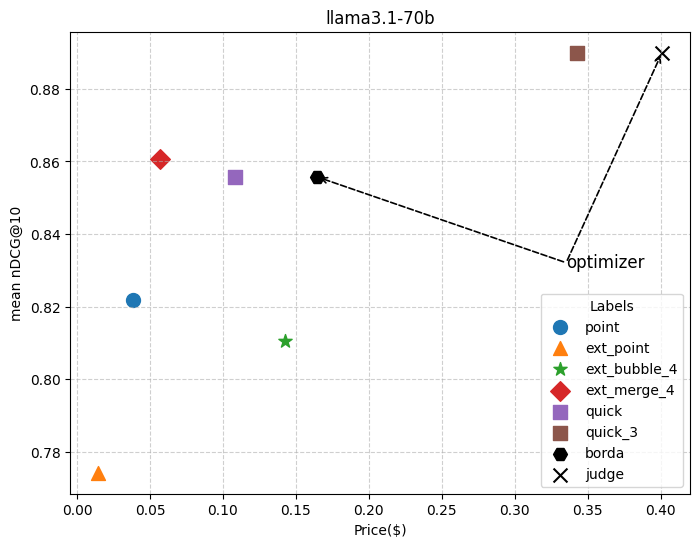

[0.857222763980806, 0.857222763980806]
opt_prices [4.302656, 4.315688]
borda 0.857222763980806
judge 0.857222763980806
-----optimal--------
best choice ['ext_merge_4'] [0.8847658971975392]
best choice mean ndcg@10 0.8847658971975392
------------------
['quick_3'] [0.857222763980806]
['quick_3'] [0.857222763980806]
point 0.380544 0.792126513008519
ext_point 0.144788 0.7647837383514495
ext_bubble_4 1.23752 0.8236732049299208
ext_merge_4 0.4753 0.8847658971975392
quick 1.613428 0.857587186079457
quick_3 3.725776 0.857222763980806
x, y 4.302656 0.857222763980806
x, y 4.315688 0.857222763980806


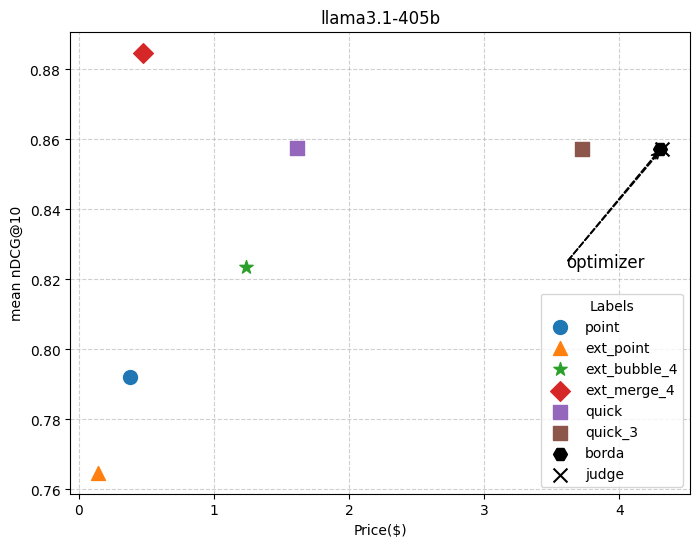

In [15]:
from scipy.optimize import curve_fit

for modelname in results.keys():
    if 'mistral' in modelname:
        continue

    alg2marker = {
        'point': 'o',
        'ext_point': '^',
        'quick': 's',
        'ext_bubble': '*',
        'ext_merge': 'D',
        'borda': 'H',
        'judge': 'x',
        'oracle': 'P', 
    }
    
    kendalltau = results[modelname]['acc']
    tokens = results[modelname]['token']
    prices = results[modelname]['price']
    dot_labels = results[modelname]['alg']
    markers = []
    for alg in dot_labels:
        if alg[-1].isdigit():
            alg = '_'.join(alg.split('_')[:-1])
        markers.append(alg2marker[alg])


    opt_acc = optimizer_results[modelname]['acc']
    print(opt_acc)
    opt_prices = optimizer_results[modelname]['price']
    print('opt_prices', opt_prices)
    opt_algs = optimizer_results[modelname]['alg']
    opt_algs = [alg.split(',')[0] for alg in opt_algs]
    for i in range(len(opt_algs)):
        if opt_algs[i] == 'llm_judge':
            opt_algs[i] = 'judge'
        elif opt_algs[i] == 'ideal':
            opt_algs[i] = 'oracle'
        print(opt_algs[i], opt_acc[i])
            
    query_acc = results[modelname]['query_acc']
    ideal_acc = query_acc[0][:]
    
    ideal_algs = [''] * len(ideal_acc)
    
    for alg, arr in zip(dot_labels, query_acc):
        assert len(arr) == 1, print(arr)
        for i in range(len(ideal_acc)):
            if arr[i] > ideal_acc[i]:
                ideal_acc[i] = arr[i]
                ideal_algs[i] = alg
            elif arr[i] == ideal_acc[i]:
                ideal_algs[i] += ',' + alg
                
    print('-----optimal--------')
    print('best choice', ideal_algs, ideal_acc)
    print('best choice mean ndcg@10', sum(ideal_acc)/len(ideal_acc) )
    print('------------------')

    for opt_alg, opt_query_acc in zip(optimizer_results[modelname]['query_alg'], optimizer_results[modelname]['query_acc']):
        print(opt_alg, opt_query_acc)
    
    # Create scatter plot
    plt.figure(figsize=(8, 6))

    for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
        print(label, x,y)
        plt.scatter(x, y, s=100, marker=m, label=label)


    for x, y, label in zip(opt_prices, opt_acc, opt_algs):
        m = alg2marker[label]
        print('x, y', x, y)
        plt.scatter(x, y, s=100, marker=m, label=label, color='k')

    text_x, text_y = 0.8, 0.5
    ax = plt.gca()

    y0 = sum(ideal_acc) / len(ideal_acc)
    # plt.axhline(y=y0, linestyle='--')
    
    for x, y in zip(opt_prices, opt_acc):
        ax.annotate(
            "",
            xy=(x, y),               # data coordinates (point)
            xycoords="data",
            xytext=(text_x, text_y), # axes fraction coordinates (label position)
            textcoords=ax.transAxes,
            arrowprops=dict(
                arrowstyle="->",
                lw=1.2,
                linestyle="--",
                color = 'k'
            ),
        )
    
    ax.text(
        text_x, text_y,
        "optimizer",
        transform=ax.transAxes,   # <-- IMPORTANT
        fontsize=12,
        ha="left",
        va="center"
    )

    

    plt.legend(title="Labels")

    # Axis labels and title
    plt.xlabel("Price($)")
    plt.ylabel("mean nDCG@10")
    plt.title(f"{modelname}")
    yticks = plt.yticks()[0]            # get current tick locations
    # plt.yticks(list(yticks) + [math.floor(y0 * 100) / 100.0])     # add the new tick 
    
    # Show grid and plot
    plt.grid(True, linestyle='--', alpha=0.6)
    # plt.savefig(f'{modelname}SembenchUnlimited.png')
    plt.show()
